# QUIZ 1 - KOMPSTAT
NAMA: ASTHAGINA DELIA PUTRI

NIM: 20244920001
## Monte Carlo Simulation untuk Estimasi Nilai π

Monte Carlo Simulation adalah metode numerik yang menggunakan bilangan acak untuk menyelesaikan masalah matematika atau probabilitas.

Pada contoh ini, kita mengestimasi nilai π dengan cara:
1. Menghasilkan titik acak (x, y) dalam persegi.
2. Menghitung berapa banyak titik yang jatuh di dalam lingkaran.
3. Menggunakan rasio tersebut untuk memperkirakan nilai π.

Rumus:
π ≈ 4 × (jumlah titik dalam lingkaran / total titik)

sumber code: https://medium.com/@whystudying/monte-carlo-simulation-with-python-13e09731d500

In [12]:
# import libraries
import numpy as np

# menginisialisasi variabel
n_simulations = 100000
n_points_circle = 0
n_points_square = 0

# buat daftar untuk menyimpan nilai x dan y
l_xs = []
l_ys = []

# ulangi sebanyak n_simulations
for _ in range(n_simulations):
    
    # x di mbil secara acak dari distribusi uniform kontinu
    x = np.random.uniform(-1, 1)
    # simpan x didalam daftar
    l_xs.append(x)
    
    # y diambil secara acak dari distribusi uniform kontinu
    y = np.random.uniform(-1, 1)
    # simpan y didalam daftar
    l_ys.append(y)
    
# ulangi sebanyak n_simulations
for i in range(n_simulations):
    
    # hitung jarak antara titik tersebut dan titik asal
    dist_from_origin = l_xs[i] ** 2 + l_ys[i] ** 2
    
    # jika jaraknya kurang dari atau sama dengan 1, titik tersebut berada di dalam lingkaran
    if dist_from_origin <= 1:
        n_points_circle += 1
    
    # Berdasarkan definisi distribusi seragam, titik tersebut terletak di dalam persegi
    n_points_square += 1
    
# estimasi nilai pi
pi = 4 * n_points_circle / n_points_square
print(pi)

3.13192


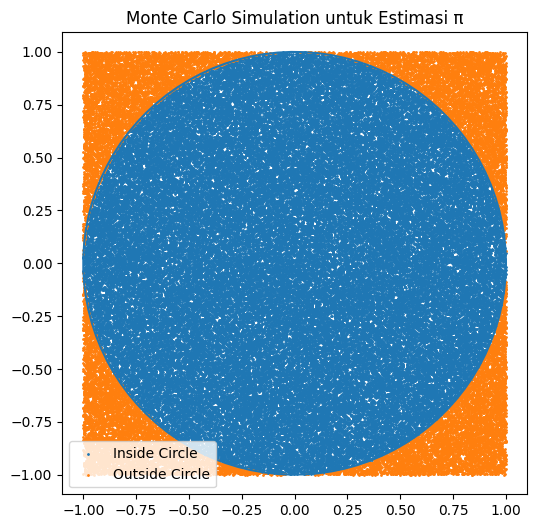

In [13]:
import matplotlib.pyplot as plt

x = np.array(l_xs)
y = np.array(l_ys)

# tentukan titik dalam lingkaran
inside = x**2 + y**2 <= 1

# buat plot
plt.figure(figsize=(6,6))

# titik di dalam lingkaran 
plt.scatter(x[inside], y[inside], s=1, label="Inside Circle")

# titik di luar lingkaran 
plt.scatter(x[~inside], y[~inside], s=1, label="Outside Circle")

# lingkaran 
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta))

# styling
plt.title("Monte Carlo Simulation untuk Estimasi π")
plt.legend()
plt.axis('equal')

plt.show()

# Markov Chain

Markov Chain adalah model probabilitas di mana keadaan berikutnya hanya bergantung pada keadaan saat ini (memoryless), tanpa dipengaruhi oleh urutan keadaan sebelumnya.

Pada simulasi ini, digunakan tiga state aktivitas, yaitu:
- Sleep
- Run
- Icecream

Perpindahan antar state diatur menggunakan *transition matrix*, yaitu:


\begin{bmatrix}
0.2 & 0.6 & 0.2 \\
0.1 & 0.6 & 0.3 \\
0.2 & 0.7 & 0.1
\end{bmatrix}


Interpretasi:

- Jika saat ini **Sleep**, maka:
  - 20% kemungkinan tetap Sleep
  - 60% kemungkinan menjadi Run
  - 20% kemungkinan menjadi Icecream

- Jika saat ini **Run**, maka:
  - 10% kemungkinan menjadi Sleep
  - 60% kemungkinan tetap Run
  - 30% kemungkinan menjadi Icecream

- Jika saat ini **Icecream**, maka:
  - 20% kemungkinan menjadi Sleep
  - 70% kemungkinan menjadi Run
  - 10% kemungkinan tetap Icecream

sumber code: https://www.datacamp.com/fr/tutorial/markov-chains-python-tutorial

In [39]:
import numpy as np
import random as rm

# Ruang state (keadaan yang mungkin terjadi)
states = ["Sleep","Icecream","Run"]

# Kemungkinan perpindahan antar state
transitionName = [["SS","SR","SI"],["RS","RR","RI"],["IS","IR","II"]]

# Matriks probabilitas transisi
transitionMatrix = [[0.2,0.6,0.2],[0.1,0.6,0.3],[0.2,0.7,0.1]]

# Fungsi untuk mensimulasikan model Markov dalam memprediksi aktivitas
def activity_forecast(days):
    # Menentukan state awal
    activityToday = "Sleep"
    print("State Awal: " + activityToday)
    
    # Menyimpan urutan state yang terjadi (diawali dengan state awal)
    activityList = [activityToday]
    i = 0
    
    # Variabel untuk menghitung probabilitas dari urutan state
    prob = 1
    
    # Perulangan sebanyak jumlah hari yang ingin diprediksi
    while i != days:
        if activityToday == "Sleep":
            # Memilih kemungkinan transisi dari state Sleep
            change = np.random.choice(transitionName[0],replace=True,p=transitionMatrix[0])
            
            if change == "SS":
                prob = prob * 0.2
                activityList.append("Sleep")
                pass
            elif change == "SR":
                prob = prob * 0.6
                activityToday = "Run"
                activityList.append("Run")
            else:
                prob = prob * 0.2
                activityToday = "Icecream"
                activityList.append("Icecream")
                
        elif activityToday == "Run":
            # Memilih kemungkinan transisi dari state Run
            change = np.random.choice(transitionName[1],replace=True,p=transitionMatrix[1])
            
            if change == "RR":
                prob = prob * 0.5
                activityList.append("Run")
                pass
            elif change == "RS":
                prob = prob * 0.2
                activityToday = "Sleep"
                activityList.append("Sleep")
            else:
                prob = prob * 0.3
                activityToday = "Icecream"
                activityList.append("Icecream")
                
        elif activityToday == "Icecream":
            # Memilih kemungkinan transisi dari state Icecream
            change = np.random.choice(transitionName[2],replace=True,p=transitionMatrix[2])
            
            if change == "II":
                prob = prob * 0.1
                activityList.append("Icecream")
                pass
            elif change == "IS":
                prob = prob * 0.2
                activityToday = "Sleep"
                activityList.append("Sleep")
            else:
                prob = prob * 0.7
                activityToday = "Run"
                activityList.append("Run")
        
        i += 1  
    
    # Menampilkan hasil simulasi
    print("Urutan state yang mungkin terjadi:" + str(activityList))
    print(f"State akhir setelah {days} hari: " + activityToday)
    print("Probabilitas dari urutan state tersebut:" + str(prob))

# Memanggil fungsi untuk memprediksi aktivitas 2 hari ke depan
activity_forecast(2)

State Awal: Sleep
Urutan state yang mungkin terjadi:['Sleep', 'Run', 'Run']
State akhir setelah 2 hari: Run
Probabilitas dari urutan state tersebut:0.3


## Hidden Markov Model (HMM)

Hidden Markov Model adalah model probabilitas di mana state tidak dapat diamati secara langsung (hidden), tetapi dapat diperkirakan melalui data observasi.

Pada simulasi ini:
- Terdapat 2 hidden states
- Setiap state menghasilkan observasi berdasarkan distribusi Gaussian
- Data observasi dihasilkan secara acak (generated data)

Tujuan:
- Mempelajari parameter model dari data
- Memprediksi hidden state berdasarkan observasi

sumber code: https://www.freecodecamp.org/news/what-is-a-markov-chain/

In [44]:
import numpy as np
from hmmlearn import hmm

# Mengatur seed random agar hasil bisa direproduksi
np.random.seed(42)

# Menentukan parameter HMM
n_components = 2  # Jumlah state (keadaan tersembunyi)
n_features = 1    # Jumlah fitur observasi

# Membuat model Gaussian HMM
model = hmm.GaussianHMM(n_components=n_components, covariance_type="diag")

# Menentukan probabilitas awal (harus berjumlah 1)
model.startprob_ = np.array([0.6, 0.4])

# Menentukan matriks transisi antar state
model.transmat_ = np.array([[0.7, 0.3],
                            [0.4, 0.6]])

# Menentukan parameter distribusi (mean dan variansi) untuk tiap state
model.means_ = np.array([[0.0], [3.0]])
model.covars_ = np.array([[0.5], [0.5]])

# Menghasilkan data observasi sintetis sebanyak 100 sampel
X, Z = model.sample(100)

# Membuat model HMM baru untuk proses training
new_model = hmm.GaussianHMM(n_components=n_components, covariance_type="diag", n_iter=100)

# Melatih model menggunakan data observasi
new_model.fit(X)

# Menampilkan parameter yang dipelajari oleh model
print("Matriks transisi:")
print(new_model.transmat_)

print("Mean tiap state:")
print(new_model.means_)

print("Variansi tiap state:")
print(new_model.covars_)

# Memprediksi state tersembunyi dari data observasi
hidden_states = new_model.predict(X)

print("State tersembunyi:")
print(hidden_states)

Matriks transisi:
[[0.8100804  0.1899196 ]
 [0.49398918 0.50601082]]
Mean tiap state:
[[0.01577373]
 [3.06245496]]
Variansi tiap state:
[[[0.41987084]]

 [[0.53146802]]]
State tersembunyi:
[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 1 1 0 1 1 0 1 0 0 0 1
 1 1 1 1 0 0 0 1 1 0 0 1 1 1 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0]


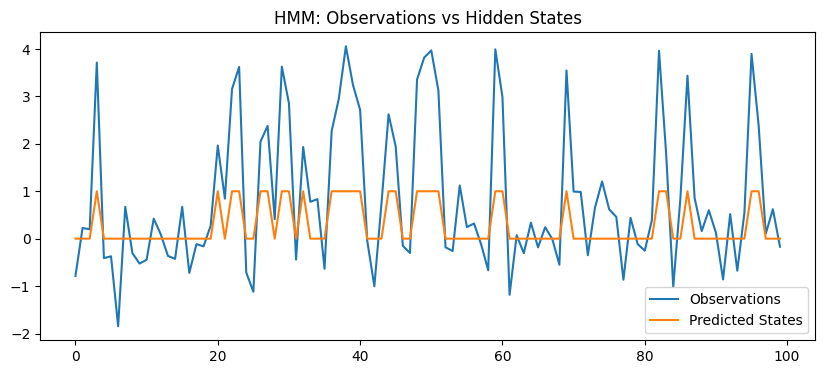

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Observasi (data yang terlihat)
plt.plot(X, label="Observations")

# Hidden state hasil prediksi
plt.plot(hidden_states, label="Predicted States")

plt.title("HMM: Observations vs Hidden States")
plt.legend()
plt.show()

Visualisasi menunjukkan hubungan antara data observasi dan hidden states.
Model HMM mencoba mengelompokkan data observasi ke dalam state tersembunyi berdasarkan pola distribusi.